In [ ]:
import wfdb
import numpy as np
signal=[]
r_peaks=[]
labels=[]
for i in range (25):
    if(i==0 or i%10!=0):
        record_name =str(100+i)
        
        record_path = 'mit-bih-arrhythmia-database-1.0.0/' + record_name
        record = wfdb.rdrecord(record_path)
        annotation = wfdb.rdann(record_path, 'atr')

        fs = record.fs  # Sampling frequency = 360 Hz
        
        r_peaks.extend(annotation.sample)

        labels.extend(annotation.symbol)  # A, N, V, etc.
        signal.extend(record.p_signal[:, 0])
for i in range (35):
    if(i!=4 and i!=6 and i!=11 and i!=16 and i!=18 and not(23<i<28)and i!=29):
        record_name =str(200+i)
        
        record_path = 'mit-bih-arrhythmia-database-1.0.0/' + record_name
        record = wfdb.rdrecord(record_path)
        annotation = wfdb.rdann(record_path, 'atr')

        fs = record.fs  # Sampling frequency = 360 Hz
        r_peaks.extend(annotation.sample)

        labels.extend(annotation.symbol)  # A, N, V, etc.
        signal.extend(record.p_signal[:, 0])


signal=np.array(signal)

labels=np.array(labels)

r_peaks=np.array(r_peaks)




N
[ 11  21  34  47  53  72  88 105 137 200 206]


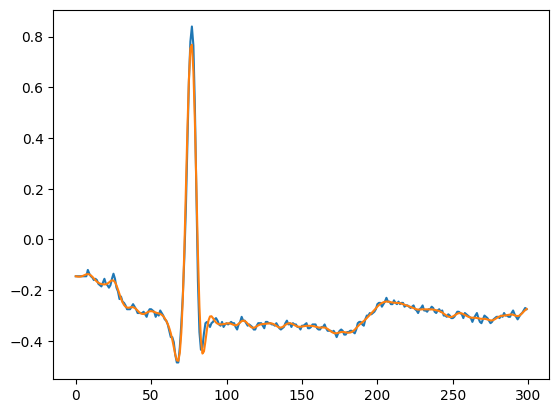

In [249]:
  # canal 1 (ex: MLII)
import scipy
import scipy.signal
import pandas as pd


def filtre_passe_bas(signal, frequence_echantillonnage, fc):
    # fc : fréquence de coupure (Hz)
    w = fc / (frequence_echantillonnage / 2)  # fréquence normalisée
    b, a = scipy.signal.butter(N=4, Wn=w, btype='low')  # N = ordre du filtre
    signal_filtré = scipy.signal.filtfilt(b, a, signal)
    return signal_filtré
X_beats = []
y_labels = []
signal1=pd.Series(signal)
signal1[:300].plot()

signal2=filtre_passe_bas(signal,record.fs,40)
signal3=pd.Series(signal2)
signal3[:300].plot()



for i, r in enumerate(r_peaks):
    r=r_peaks[2]
    start = r - 72
    end = r + 144
   
   

    # Vérifier que les bords ne dépassent pas
    if start >= 0 and end < len(signal):
       
        beat1=[]
        print(labels[2])
        beat = signal2[start:end]
        beat=pd.Series(beat)
        
        #beat.plot()
        beat=filtre_passe_bas(beat,record.fs,35)
        #print(r_peaks[i])
        #print(signal[r_peaks[i]])
      
        beat=pd.Series(beat)
        #beat.plot()
       
        r_peaks1,meta=scipy.signal.find_peaks(beat)
        print(r_peaks1)
        #print(r_peaks1)
        #print(beat[r_peaks1+1])
       # r_peaks1,meta=scipy.signal.find_peaks(beat,height=-0.3)
        #print(r_peaks1)
        
        break
        
      
    
        
        j=0.1
        while(len(r_peaks1)==0):
            r_peaks1,meta=scipy.signal.find_peaks(beat,height=0.5-j)
            j+=0.1
            
        beat1.append(r_peaks[i])
        beat1.append(signal[r_peaks[i]])
        X_beats.append(beat1)
        y_labels.append(labels[i])
    break
#print(type(X_beats))


In [148]:
X_beats = np.array(X_beats)
y_labels = np.array(y_labels)

# Z-score normalization
X_beats = (X_beats - X_beats.mean(axis=1, keepdims=True)) / X_beats.std(axis=1, keepdims=True)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Encode labels (facultatif si tu as 'N', 'V', etc.)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)

X_train, X_test, y_train, y_test = train_test_split(X_beats, y_encoded, test_size=0.2, random_state=42,stratify=y_labels)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(clf.score(X_test, y_test))

print(classification_report(y_test, y_pred,labels=le.transform(le.classes_), target_names=le.classes_))


0.666489054660095
              precision    recall  f1-score   support

           !       0.00      0.00      0.00        94
           "       0.00      0.00      0.00        87
           +       0.00      0.00      0.00       251
           /       0.00      0.00      0.00      1406
           A       0.00      0.00      0.00       509
           E       0.00      0.00      0.00        21
           F       0.00      0.00      0.00       160
           J       0.00      0.00      0.00        17
           L       0.00      0.00      0.00      1615
           N       0.67      1.00      0.80     15010
           Q       0.00      0.00      0.00         7
           R       0.00      0.00      0.00      1452
           S       0.00      0.00      0.00         0
           V       0.00      0.00      0.00      1426
           [       0.00      0.00      0.00         1
           ]       0.00      0.00      0.00         1
           a       0.00      0.00      0.00        30
         

c:\Users\msi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\msi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\msi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,